# 1.
Build a simple autoencoder in Python using Keras to compress and reconstruct 28x28 grayscale images from the Fashion MNIST dataset. Train for 5 epochs and display one original and its reconstructed image side by side.

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3917 - val_loss: 0.3297
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3153 - val_loss: 0.3075
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2987 - val_loss: 0.2955
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2893 - val_loss: 0.2882
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2840 - val_loss: 0.2844
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step


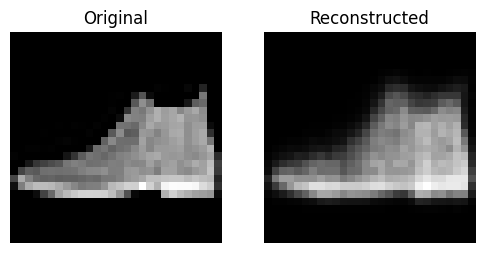

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

# Load Fashion MNIST dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Autoencoder architecture
input_img = Input(shape=(28, 28))

# Encoder
x = Flatten()(input_img)
encoded = Dense(64, activation='relu')(x)

# Decoder
decoded = Dense(28 * 28, activation='sigmoid')(encoded)
decoded = Reshape((28, 28))(decoded)

# Build autoencoder model
autoencoder = Model(input_img, decoded)

# Compile model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train for 5 epochs
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Reconstruct images
reconstructed = autoencoder.predict(x_test)

# Display one original and reconstructed image
plt.figure(figsize=(6, 3))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(x_test[0], cmap='gray')
plt.title("Original")
plt.axis('off')

# Reconstructed image
plt.subplot(1, 2, 2)
plt.imshow(reconstructed[0], cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()

# 2.
Modify your autoencoder's loss function to use Binary Crossentropy (BCE) instead of Mean Squared Error (MSE), then compare the reconstruction quality visually for 3 test images.<br><br><em><strong>Hint:</strong> Use model.compile(loss='binary_crossentropy', optimizer='adam').</em>

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3932 - val_loss: 0.3275
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3138 - val_loss: 0.3050
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2965 - val_loss: 0.2932
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2879 - val_loss: 0.2876
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2835 - val_loss: 0.2841
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step


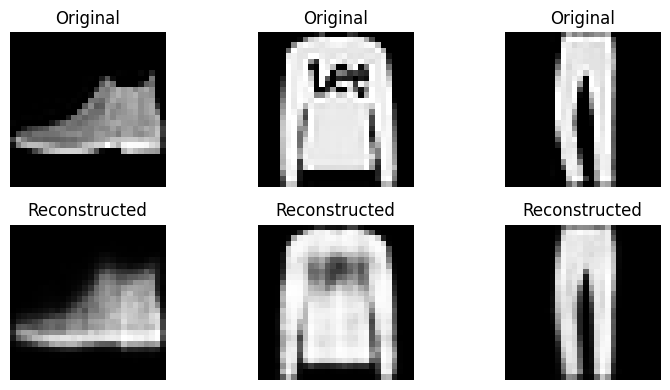

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

# Load Fashion MNIST
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Autoencoder Architecture
input_img = Input(shape=(28, 28))

# Encoder
x = Flatten()(input_img)
encoded = Dense(64, activation='relu')(x)

# Decoder
decoded = Dense(28 * 28, activation='sigmoid')(encoded)
decoded = Reshape((28, 28))(decoded)

# Build model
autoencoder = Model(input_img, decoded)

# Compile using Binary Crossentropy
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Train model
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Reconstruct test images
reconstructed = autoencoder.predict(x_test)

# Display 3 original and reconstructed images
n = 3
plt.figure(figsize=(8, 4))

for i in range(n):
    # Original image
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 3.
Use your trained autoencoder to denoise images: add random noise to 10 Fashion MNIST test images, pass them through the autoencoder, and display the noisy and denoised outputs together.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


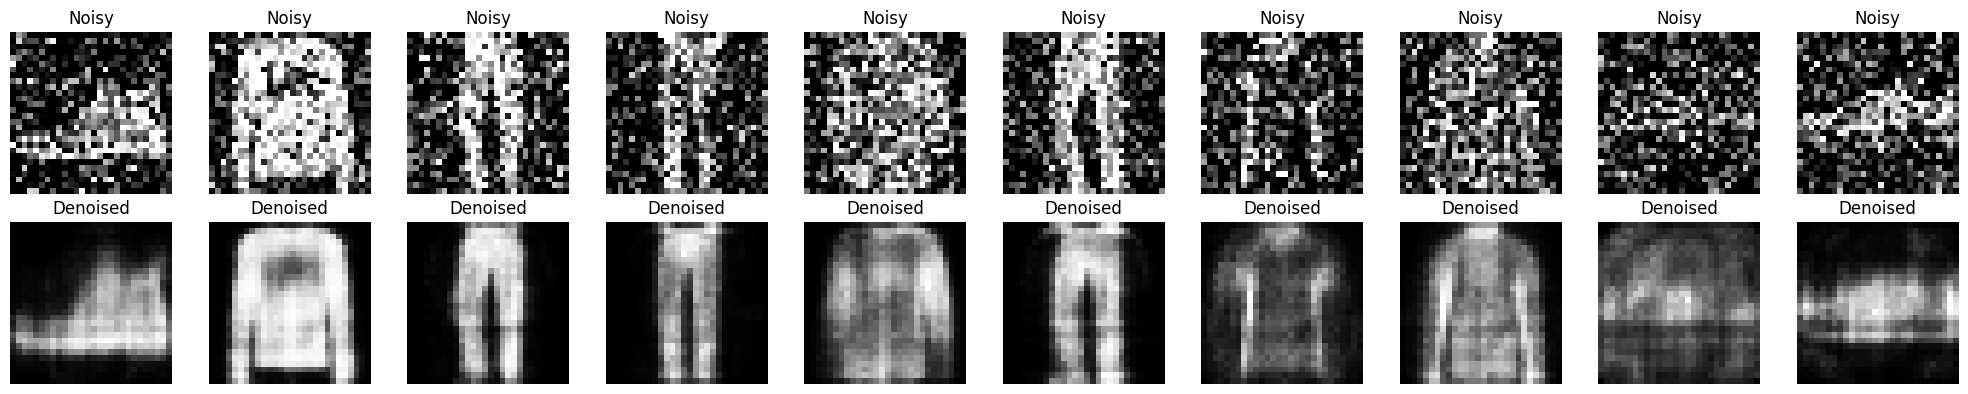

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Assume 'autoencoder' has already been trained
# and x_test has already been loaded and normalized

# Select 10 test images
n = 10
test_images = x_test[:n]

# Add Gaussian noise
noise_factor = 0.4
noisy_images = test_images + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=test_images.shape
)

# Keep pixel values in valid range
noisy_images = np.clip(noisy_images, 0., 1.)

# Denoise using autoencoder
denoised_images = autoencoder.predict(noisy_images)

# Display noisy and denoised images
plt.figure(figsize=(20, 4))

for i in range(n):
    # Noisy image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(noisy_images[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(denoised_images[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 4.
Build a Variational Autoencoder (VAE) using Keras for the Fashion MNIST dataset. After training, sample 5 random points from the latent space and generate new images from these points.<br><br><em><strong>Hint:</strong> Use the VAE's decoder to generate images from sampled latent vectors.</em>

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 6.3115 - loss: 281.0273 - reconstruction_loss: 274.7158
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 6.4190 - loss: 282.4691 - reconstruction_loss: 276.0501
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 6.6138 - loss: 276.2951 - reconstruction_loss: 269.6813
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 6.3717 - loss: 267.5222 - reconstruction_loss: 261.1506
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.9318 - loss: 268.2626 - reconstruction_loss: 262.3308
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 6.7612 - loss: 262.0333 - reconstruction_loss: 255.2721
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 6.2809 - loss: 276.0638 - reconstruction_loss: 269.7830
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.5427 - loss: 267.9618 - reconstruction_loss: 261.4191
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/s

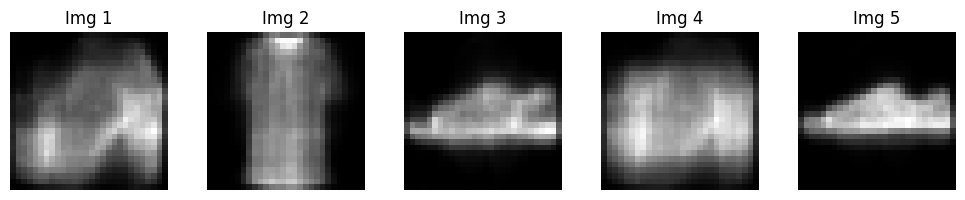

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load Fashion MNIST
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize and flatten
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Parameters
input_dim = 784
hidden_dim = 256
latent_dim = 2

# Encoder
encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(hidden_dim, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(hidden_dim, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

# VAE Model
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                        )
                ) * input_dim
            

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

vae = VAE(encoder, decoder)

vae.compile(optimizer="adam")

# Train VAE
vae.fit(
    x_train,
    epochs=10,
    batch_size=128
)

# Sample 5 random latent vectors
random_latent_vectors = np.random.normal(
    size=(5, latent_dim)
)

# Generate new images
generated_images = decoder.predict(
    random_latent_vectors
)

# Display generated images
plt.figure(figsize=(10, 2))

for i in range(5):
    ax = plt.subplot(1, 5, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")
    plt.title(f"Img {i+1}")

plt.tight_layout()
plt.show()

# 5.
Use ChatGPT to explain in your own words what KL-divergence loss does in a VAE and why it is needed. Paste your prompt and ChatGPT's response as your answer.

# Prompt Used

Explain in simple terms what KL-divergence loss does in a Variational Autoencoder (VAE) and why it is needed. Provide the explanation in a way that a beginner in deep learning can understand.

# ChatGPT's Response

KL-divergence (Kullback-Leibler Divergence) is a loss term used in Variational Autoencoders (VAEs) to ensure that the latent space follows a standard normal distribution (mean = 0 and variance = 1).

A VAE has two objectives:

1. **Reconstruction Loss** – Ensures that the decoder can accurately reconstruct the input image from its latent representation.
2. **KL-Divergence Loss** – Ensures that the latent representations are organized and follow a smooth probability distribution.

Without KL-divergence loss, the encoder could place data points randomly in the latent space. This would make it difficult to generate new meaningful images because random samples from the latent space might not correspond to valid outputs.

KL-divergence acts as a regularizer. It encourages the latent vectors to stay close to a standard normal distribution, making the latent space smooth and continuous. As a result, nearby points in the latent space generate similar outputs, and random sampling becomes possible.

In simple words, reconstruction loss helps the VAE remember the data, while KL-divergence helps it organize the latent space so that it can generate new realistic data samples.